In [2]:
#import the TensorFlow library and Keras utilities
import tensorflow as tf
from tensorflow.keras import datasets, layers, models


/Users/sita/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
#load the fashion MNIST dataset
data = datasets.fashion_mnist
(ip_train, op_train),(ip_test, op_test) = data.load_data()

In [4]:
#check the shape of the images
print(ip_train.shape, ip_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [5]:
#reshape the input values
ip_train = ip_train.reshape((60000, 28, 28, 1))
ip_test = ip_test.reshape((10000, 28, 28, 1))
print(ip_train.shape, ip_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [6]:
#prepare the data
ip_train, ip_test = ip_train/255.0, ip_test/255.0

In [13]:
#build the convolutional neural network
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))

/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#add the final dense layer and output layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [15]:
#compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )

In [16]:
#view the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#train the model
model.fit(ip_train, op_train, epochs=7)

Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9249 - loss: 0.2012
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9299 - loss: 0.1867
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9374 - loss: 0.1659
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9425 - loss: 0.1535
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9500 - loss: 0.1355
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9533 - loss: 0.1257
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9566 - loss: 0.1143


In [20]:
#test the model
model.evaluate(ip_test, op_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9153 - loss: 0.2932


[0.2860986292362213, 0.9139000177383423]

In [21]:
#Inferencing
import numpy as np
from tensorflow.keras.models import load_model
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']   


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
predicted: 2 Pullover prob: 0.86868656
ground truth: 9 Ankle boot


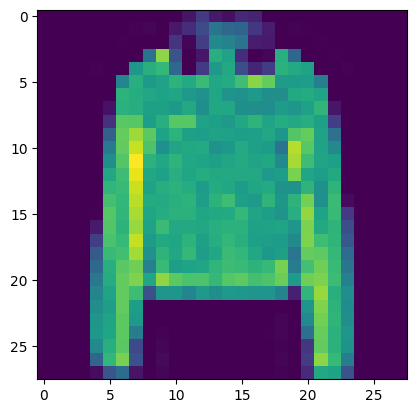

In [28]:
# 1) Single-image inference (first test image)
test_image = ip_test[4500].astype('float32')         # ip_test already normalized in notebook
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(test_image.reshape(28,28))


test_image = test_image.reshape((1, 28, 28, 1))             # add batch dimension
pred = model.predict(test_image)[0]                # probabilities
pred_class = np.argmax(pred)
print("predicted:", pred_class, class_names[pred_class], "prob:", pred[pred_class])
print("ground truth:", op_test[0], class_names[op_test[0]])


In [26]:
 #2) Batch inference on the test set
preds = model.predict(ip_test)            # shape (10000, 10)
pred_labels = np.argmax(preds, axis=1)
print("accuracy on test subset:", np.mean(pred_labels == op_test))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
accuracy on test subset: 0.9139


In [27]:
# 3) Save model for later use and load for inference
model.save('fashion_cnn.h5')
# later (in a new script/notebook):
# loaded = load_model('fashion_cnn.h5')
# preds = loaded.predict(some_input)
# ...existing code...